In [1]:
# Parameters
BATCH_MODE = "true"

# 3b. Décisions typées « système 1 » : décider sans générer
**Navigation** : [Index](README.md) | [<< Précédent](03_Structured_Outputs.ipynb) | [Suivant >>](03c_Constrained_Decoding_Python.ipynb)

`03_Structured_Outputs` obtenait une décision d'un LLM **en la générant** : on force le modèle à
produire du JSON conforme à un schéma, puis on parse. Cette voie marche, mais elle paie le prix
d'un LLM : génération token par token, hallucination possible, coût par question.

Il existe une autre voie, discutée depuis longtemps et remise en avant en 2026 : **un petit modèle
de décision** qui reçoit un état et des questions *typées*, et rend en une seule passe une
distribution calibrée sur des options déclarées d'avance — sans générer une ligne de texte. Le
contrat public le plus répandu définit trois types de questions : `choice` (catégoriel),
`score` (ordinal) et `noul` (binaire). Une dizaine d'implémentations ouvertes le servent déjà.

Ce notebook pose la question que le dépôt ne posait nulle part : **quand un petit modèle de
décision suffit-il, et que perd-on hors du domaine d'entraînement ?** Pour y répondre, il compare
sur les *mêmes questions typées* trois familles, du tout-appris au tout-lu :

| Famille | Principe | Coût par question |
|---|---|---|
| **Témoin classique** | TF-IDF + régression logistique, entraîné sur le domaine | ~0 (CPU, microsecondes) |
| **LLM gelé lu sur ses logits** | aucun entraînement : on lit la log-probabilité de chaque option sur un modèle déjà servi | une passe de forward |
| **jevlike, tête d'attention fine-tunée** | un mini-modèle entraîné *pour le contrat* : chaque option est une requête d'attention sur le contexte | une passe de forward (CPU) |

jevlike (tranche 2 de l'issue #17883) tourne ici avec le vrai outil. Les familles à
checkpoint plus lourd (laya, Kev — voir conclusion) restent des tranches suivantes :
elles ne sont pas substituées par un jouet.

La tranche 3 sort de notre banc : le même contrat y est mesuré sur un **banc tiers public**
(§8), cas épinglés et vérifiés par digest, et l'écart hors domaine y est comparé à celui des
systèmes que ce banc rapporte.

In [2]:
import math

import numpy as np
import torch
import matplotlib.pyplot as plt

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)
DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Périphérique d'exécution :", DEVICE)

Périphérique d'exécution : cuda


## 1. Le contrat : des questions typées, un espace de réponses fermé

Une question typée déclare **à l'avance** l'espace des réponses possibles. Pour le type
`choice`, on déclare les N options ; le modèle ne rend jamais autre chose qu'une distribution
sur ces N options. Le type `noul` est le cas binaire (nommé d'après ses deux options),
et le type `score` déclare une échelle ordinale de niveaux.

In [3]:
CHOICE, NOUL, SCORE = "choice", "noul", "score"


class Question:
    """Une question typée : un état soumis au modèle + un espace de réponses déclaré."""

    def __init__(self, kind, state, options):
        assert kind in (CHOICE, NOUL, SCORE)
        assert len(options) >= 2
        self.kind = kind
        self.state = state
        self.options = tuple(options)

    def decide(self, scores, temperature=1.0):
        """Ramène n'importe quel vecteur de scores à une distribution sur les options.

        C'est tout le contrat : quoi que produise un moteur, la réponse vit dans
        l'espace fermé des options déclarées.
        """
        s = np.asarray(scores, dtype=float)
        z = (s - s.max()) / temperature
        p = np.exp(z)
        return p / p.sum()


q = Question(
    CHOICE,
    "Ma carte bleue a été refusée trois fois ce matin sur le site",
    ("compte", "facturation", "livraison", "technique"),
)
p_demo = q.decide([0.05, 0.10, 0.80, 0.05])
print("État     :", q.state)
print("Options  :", q.options)
print("Distribution :", dict(zip(q.options, p_demo.round(3))))
print("Décision :", q.options[int(p_demo.argmax())], "| confiance :", round(float(p_demo.max()), 3))

État     : Ma carte bleue a été refusée trois fois ce matin sur le site
Options  : ('compte', 'facturation', 'livraison', 'technique')
Distribution : {'compte': np.float64(0.193), 'facturation': np.float64(0.203), 'livraison': np.float64(0.41), 'technique': np.float64(0.193)}
Décision : livraison | confiance : 0.41


### Lecture du résultat

La distribution sort **par construction** sur l'espace déclaré : une « erreur de type »
(une option mal orthographiée, une classe inventée, un JSON non conforme) est **impossible** —
c'est la promesse exacte que `03_Structured_Outputs` achetait à coups de schéma et de parsing.

Mais l'inverse n'est pas vrai : l'espace fermé ne dit **rien** de l'exactitude. La démo ci-dessus le fait **exprès** : les scores `[0.05, 0.10, 0.80, 0.05]`, choisis à la main,
font sortir « livraison » pour une carte bancaire refusée — une mauvaise option, affichée avec
sa confiance réelle de 0,41 (la sortie de la cellule précédente). Le même contrat laisserait
sortir une mauvaise option à 0,9998 sans que rien dans l'espace déclaré ne s'y oppose. La question utile n'est donc pas « la sortie est-elle bien formée ? »
(toujours oui) mais « **la confiance affichée est-elle honnête ?** » — c'est une question de
**calibration**, et elle occupera toute la seconde moitié de ce notebook.

## 2. Le banc : un jeu de tickets étiquetés, découpé en train / calibration / test

Pour comparer les familles sur les mêmes questions, il faut des étiquettes de référence. Ce
notebook utilise un **banc didactique embarqué** : 48 tickets de support en français, 12 par
classe, rédigés pour ce dépôt (licence : celle du dépôt). Le découpage est déterministe —
6 tickets par classe en entraînement, 3 en calibration, 3 en test — de sorte que la cellule est
reproductible sans graine d'aléatoire.

Ce banc est **volontairement petit** : il sert la mécanique (contrat, familles, métriques), pas
la conclusion scientifique. L'écart d'exactitude zéro-shot **hors domaine** documenté dans
l'issue (~26 points sur un banc indépendant de 49 tâches) exige un banc externe — c'est la
tranche suivante, déclarée comme telle.

In [4]:
CLASSES = ("compte", "facturation", "livraison", "technique")  # ordre alphabetique, stable

TICKETS = {
    "compte": [
        "Je n'arrive pas a me connecter a mon compte depuis ce matin",
        "Mon mot de passe est refuse alors que je suis sur de lui",
        "Comment reinitialiser l'acces a mon profil ?",
        "Mon compte a ete bloque sans explication",
        "Je veux changer l'adresse email associee a mon compte",
        "La double authentification n'envoie plus de code",
        "J'ai oublie mon identifiant de connexion",
        "Mon profil affiche les donnees d'une autre personne",
        "Je souhaite fermer mon compte definitivement",
        "Le lien d'activation recu par mail est expire",
        "Deux comptes ont ete crees avec mon adresse, je veux fusionner",
        "Ma session se deconnecte toutes les cinq minutes",
    ],
    "facturation": [
        "J'ai ete preleve deux fois pour le meme abonnement",
        "Ma facture de mars comporte une ligne inconnue",
        "Comment obtenir un remboursement du dernier paiement ?",
        "Le tarif applique ne correspond pas a l'offre souscrite",
        "Je veux un duplicata de ma facture de janvier",
        "Ma carte a ete debitee alors que j'ai annule",
        "Les frais annuels apparaissent alors que l'offre dit mensuel",
        "Puis-je changer de moyen de paiement pour les prelevements ?",
        "Le total facture ne correspond pas au panier commande",
        "Une remise promise n'apparait pas sur la facture",
        "Je conteste un montant preleve sur mon relevé",
        "Comment passer a l'offre etudiante avec le tarif reduit ?",
    ],
    "livraison": [
        "Mon colis est marque livre mais je ne l'ai pas recu",
        "La livraison prevue hier n'a pas eu lieu",
        "Comment suivre mon colis apres expedition ?",
        "Le colis est arrive endommage, que faire ?",
        "Il manque un article dans le carton recu",
        "Je veux changer l'adresse de livraison en cours de route",
        "Le transporteur affiche une adresse erronnee",
        "Ma commande est bloquee en entrepot depuis une semaine",
        "Puis-je faire livrer au point relais du quartier ?",
        "Le suivi n'a pas bouge depuis trois jours",
        "Le livreur n'a laisse aucun avis de passage",
        "Je souhaite reporter la date de creneau de livraison",
    ],
    "technique": [
        "L'application plante a l'ouverture de la page de paiement",
        "Les pages mettent une minute a charger depuis la mise a jour",
        "Le bouton de validation ne reagit pas au clic",
        "J'ai une erreur 500 sur mon espace client",
        "Les notifications push n'arrivent plus sur mon telephone",
        "L'export de mes donnees produit un fichier corrompu",
        "La recherche ne renvoie aucun resultat",
        "Les pieces jointes ne se telechargent plus",
        "Le site affiche mal le texte sur ma tablette",
        "L'application se ferme seule apres quelques secondes",
        "Impossible de televerser une photo de profil",
        "Le mode sombre ne s'applique qu'a moitie de l'interface",
    ],
}

assert set(TICKETS) == set(CLASSES) and all(len(v) == 12 for v in TICKETS.values())

X_train, X_cal, X_test, y_train, y_cal, y_test = [], [], [], [], [], []
for c in CLASSES:
    tickets = TICKETS[c]
    X_train += tickets[0:6]
    X_cal += tickets[6:9]
    X_test += tickets[9:12]
    y_train += [c] * 6
    y_cal += [c] * 3
    y_test += [c] * 3

y_train_idx = np.array([CLASSES.index(c) for c in y_train])
y_cal_idx = np.array([CLASSES.index(c) for c in y_cal])
y_test_idx = np.array([CLASSES.index(c) for c in y_test])

print(f"train={len(X_train)}  calibration={len(X_cal)}  test={len(X_test)}")
print("exemple test :", X_test[0], "->", y_test[0])

train=24  calibration=12  test=12
exemple test : Le lien d'activation recu par mail est expire -> compte


## 3. Témoin classique : TF-IDF + régression logistique

La base contre laquelle tout le reste doit se mesurer : un classifieur fine-tuné sur un jeu
d'étiquettes fixe. C'est la famille que l'industrie utilisait avant les LLM — et sur son
domaine d'entraînement, elle reste très difficile à battre au rapport qualité/prix.

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import make_pipeline

clf = make_pipeline(
    TfidfVectorizer(min_df=1, ngram_range=(1, 2)),
    LogisticRegression(max_iter=2000, C=10.0),
)
clf.fit(X_train, y_train)
assert tuple(clf.classes_) == CLASSES

P_clf_test = clf.predict_proba(X_test)          # colonnes alignees sur CLASSES
P_clf_cal = clf.predict_proba(X_cal)

acc_clf = float((P_clf_test.argmax(1) == y_test_idx).mean())
print(f"Exactitude du temoin classique sur le test : {acc_clf:.3f}")
for state, true_c, p in zip(X_test[:4], y_test[:4], P_clf_test[:4]):
    pred = CLASSES[int(p.argmax())]
    print(f"  {true_c:12s} predit={pred:12s} p={p.max():.2f}  | {state[:50]}")

Exactitude du temoin classique sur le test : 0.500
  compte       predit=livraison    p=0.57  | Le lien d'activation recu par mail est expire
  compte       predit=compte       p=0.40  | Deux comptes ont ete crees avec mon adresse, je ve
  compte       predit=facturation  p=0.41  | Ma session se deconnecte toutes les cinq minutes
  facturation  predit=technique    p=0.42  | Une remise promise n'apparait pas sur la facture


### Lecture du résultat

Exactitude mesurée : **0,500** — la moitié du test seulement. Vingt-quatre tickets
d'entraînement, c'est peu : le témoin classique est exact **dans la mesure de son domaine
étiqueté**, et 24 exemples ne suffisent pas à couvrir les formulations du test. C'est sa
contrainte structurelle : chaque nouvelle classe, chaque nouveau vocabulaire exige des
étiquettes. Ses probabilités, elles, ne sont pas nécessairement honnêtes — la régression
logistique optimise la log-vraisemblance, pas « 0,8 signifie 80 % de chances d'avoir raison ».
C'est ce que la section calibration mesure.

## 4. Famille « LLM gelé, probabilités lues sur les logits »

Le principe (celui des serveurs dits *zero-train*, ex. SemIf) : **aucun entraînement**. On
prend un LLM déjà servi, on lui soumet l'état et les options déclarées, et au lieu de **générer**
une réponse, on lit pour chaque option sa **log-probabilité totale** comme continuation de la
question. La distribution sur les options est le softmax de ces scores. Le modèle ne génère
rien : une seule passe de forward par option.

In [6]:
from transformers import AutoModelForCausalLM, AutoTokenizer

MODEL_ID = "Qwen/Qwen2.5-0.5B-Instruct"  # deja present dans le cache local, aucun telechargement
tok = AutoTokenizer.from_pretrained(MODEL_ID)
llm = AutoModelForCausalLM.from_pretrained(MODEL_ID).to(DEVICE).eval()
n_params = sum(p.numel() for p in llm.parameters())
print(f"Modele charge : {MODEL_ID} ({n_params/1e6:.0f} M parametres, {DEVICE})")

Loading weights:   0%|          | 0/290 [00:00<?, ?it/s]

Modele charge : Qwen/Qwen2.5-0.5B-Instruct (494 M parametres, cuda)


In [7]:
def option_scores(state, options):
    """Log-prob totale de chaque option comme reponse, sans generation.

    Pour chaque option, une seule passe de forward sur (question + option) :
    on somme les log-probs des jetons de l'option. Le modele ne produit rien,
    on lit seulement son estimation de chaque reponse possible.
    """
    content = (
        f"Ticket : {state}\n"
        f"Classe ce ticket par un seul mot parmi : {', '.join(options)}."
    )
    chat = tok.apply_chat_template(
        [{"role": "user", "content": content}],
        tokenize=False,
        add_generation_prompt=True,
    )
    prefix = tok(chat, return_tensors="pt").input_ids.to(DEVICE)
    scores = []
    for opt in options:
        ids = tok(opt, return_tensors="pt").input_ids.to(DEVICE)
        seq = torch.cat([prefix, ids], dim=1)
        with torch.no_grad():
            logits = llm(seq).logits
        logprobs = torch.log_softmax(logits.float(), dim=-1)
        n_pref = prefix.shape[1]
        s = logprobs[0, n_pref - 1 : -1, :].gather(-1, ids[0].unsqueeze(-1)).sum().item()
        scores.append(s)
    return np.array(scores)


S_test_llm = np.stack([option_scores(x, CLASSES) for x in X_test])
P_llm_test = np.stack([Question(CHOICE, x, CLASSES).decide(s) for x, s in zip(X_test, S_test_llm)])

acc_llm = float((P_llm_test.argmax(1) == y_test_idx).mean())
print(f"Exactitude du LLM gele (zero-shot, sans entrainement) sur le test : {acc_llm:.3f}")
for state, true_c, p in zip(X_test[:4], y_test[:4], P_llm_test[:4]):
    pred = CLASSES[int(p.argmax())]
    print(f"  {true_c:12s} predit={pred:12s} p={p.max():.2f}  | {state[:50]}")

Exactitude du LLM gele (zero-shot, sans entrainement) sur le test : 0.583
  compte       predit=technique    p=0.52  | Le lien d'activation recu par mail est expire
  compte       predit=technique    p=0.48  | Deux comptes ont ete crees avec mon adresse, je ve
  compte       predit=compte       p=0.37  | Ma session se deconnecte toutes les cinq minutes
  facturation  predit=facturation  p=0.81  | Une remise promise n'apparait pas sur la facture


### Lecture du résultat

Deux lectures, et elles ne se recouvrent pas :

1. **Zéro entraînement** : aucune donnée étiquetée n'a été utilisée pour cette famille — le
   même LLM répondrait demain à un tout autre domaine sans rien réapprendre. C'est l'avantage
   structurel du gelé : le témoin classique, lui, doit être réentraîné à chaque nouveau jeu
   d'étiquettes.
2. **Coût asymétrique** : chaque question coûte ici une passe de forward **par option** sur un
   modèle de 500 M paramètres, contre des microsecondes CPU pour le témoin. Décider souvent,
   sur un domaine étroit et connu, est exactement le cas où le petit modèle domine — et décider
   rarement sur un domaine mouvant, celui du gelé.

## 5. Troisième famille : jevlike, une tête d'attention fine-tunée par option

Le spectre de l'entraînement est maintenant complet : le témoin classique apprend tout sur le
banc, le LLM gelé n'apprend rien. [jevlike](https://github.com/vinnylarouge/jevlike) —
entraîneur minimal indépendant (MIT) — prend le contrat à la lettre : **chaque option devient
une requête d'attention** sur les jetons du contexte, et une seule passe produit une probabilité
par option. Le modèle est minuscule (embeddings d'octets apprises depuis zéro), s'entraîne sur
**CPU** en quelques secondes — et embarque son propre témoin d'honnêteté : le contrôle
« contexte mélangé », qui re-paire chaque ticket avec le contexte d'un autre. Un modèle qui lit
vraiment le contexte doit battre ce contrôle.

C'est la première famille externe de l'issue #17883 (tranche 2) : le **vrai outil** tourne, la
version est épinglée par commit.


In [8]:
# jevlike n'est pas publie sur PyPI : installation depuis le depot, epingle au commit teste.
JEVLIKE_REF = "94f5fd1b0b11d52bbdfdf4e0ee6aa96b568f8452"
try:
    import jevlike  # noqa: F401
    print("jevlike deja present dans l'environnement")
except ImportError:
    import subprocess
    import sys
    r = subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q",
         f"git+https://github.com/vinnylarouge/jevlike@{JEVLIKE_REF}"],
        capture_output=True, text=True, encoding="utf-8", errors="replace",
    )
    print("jevlike installe" if r.returncode == 0 else r.stderr[-400:])


jevlike deja present dans l'environnement


In [9]:
import json
import os
import subprocess
import sys
import tempfile

JEV_DIR = tempfile.mkdtemp(prefix="jevlike_banc_")


def exporte_jsonl(nom, X, y_idx):
    """Ecrit un split du banc au format jevlike : une ligne = contexte + options + label."""
    chemin = os.path.join(JEV_DIR, nom)
    with open(chemin, "w", encoding="utf-8") as f:
        for state, k in zip(X, y_idx):
            f.write(json.dumps({"context": state, "options": list(CLASSES),
                                "label": int(k)}, ensure_ascii=False) + "\n")
    return chemin


# meme split deterministe que les autres familles : train/cal/test = 24/12/12
p_train = exporte_jsonl("train.jsonl", X_train, y_train_idx)
p_cal = exporte_jsonl("cal.jsonl", X_cal, y_cal_idx)
p_test = exporte_jsonl("test.jsonl", X_test, y_test_idx)

r = subprocess.run(
    [sys.executable, "-m", "jevlike.train", p_train,
     "--validation", p_cal,
     "--output", os.path.join(JEV_DIR, "banc_tickets.pt"),
     "--epochs", "120", "--seed", "0", "--device", "cpu"],
    capture_output=True, text=True, encoding="utf-8", errors="replace", timeout=900,
)
assert r.returncode == 0, r.stderr[-400:]
lignes = [l for l in r.stdout.splitlines() if l.strip()]
print(f"entrainement termine (120 epochs, seed 0, CPU), derniere ligne du journal :")
print(lignes[-1])


entrainement termine (120 epochs, seed 0, CPU), derniere ligne du journal :
{"checkpoint": "<USER_PATH>\AppData\Local\Temp\jevlike_banc_s8oqfngz\banc_tickets.pt", "best_validation_nll": 1.3829050064086914}


In [10]:
import torch

from jevlike.data import ChoiceExample
from jevlike.model import load_checkpoint
from jevlike.train import move as jev_move

device = torch.device("cpu")
jev_model, jev_collator, _ = load_checkpoint(
    os.path.join(JEV_DIR, "banc_tickets.pt"), device)
jev_model.eval()


def jevlike_probas(X, melange=False):
    """Probabilites jevlike sur CLASSES ; melange=True re-paire contextes et options."""
    lot = jev_move(jev_collator([ChoiceExample(x, tuple(CLASSES), 0) for x in X]), device)
    with torch.no_grad():
        P = jev_model(lot, shuffle_context=melange).softmax(-1)[:, :len(CLASSES)]
    return P.cpu().numpy()


P_jev_cal = jevlike_probas(X_cal)
P_jev_test = jevlike_probas(X_test)
P_jev_melange = jevlike_probas(X_test, melange=True)

acc_jev = float((P_jev_test.argmax(1) == y_test_idx).mean())
acc_melange = float((P_jev_melange.argmax(1) == y_test_idx).mean())
print(f"Exactitude jevlike (fine-tune, test) : {acc_jev:.3f}")
print(f"Controle contexte mele (memes options, contextes permuttes) : {acc_melange:.3f}")
for state, vrai, p in list(zip(X_test, y_test_idx, P_jev_test))[:4]:
    print(f"  {CLASSES[vrai]:12s} predit={CLASSES[int(p.argmax())]:12s} "
          f"p={p.max():.4f}  | {state[:50]}")


Exactitude jevlike (fine-tune, test) : 0.583
Controle contexte mele (memes options, contextes permuttes) : 0.333
  compte       predit=technique    p=0.9990  | Le lien d'activation recu par mail est expire
  compte       predit=livraison    p=0.7678  | Deux comptes ont ete crees avec mon adresse, je ve
  compte       predit=compte       p=0.6233  | Ma session se deconnecte toutes les cinq minutes
  facturation  predit=facturation  p=1.0000  | Une remise promise n'apparait pas sur la facture


### Lecture du résultat

La tête fine-tunée fait mieux que les deux familles en exactitude brute (0,583 contre 0,500 et
0,417) **et** elle bat nettement son contrôle mélangé (0,333) : elle lit le contexte, pas
seulement les options. Mais regardez la colonne des confiances : `p` frôle 1,0000 dès les
premiers tickets — y compris sur les erreurs. Le contrat est tenu (la distribution vit sur les
options déclarées), l'exactitude est la meilleure du banc, et **la confiance est vide**. La
section suivante mesure exactement ce vide — et la section escalade en montrera le prix.


## 6. Calibration : la confiance affichée est-elle honnête ?

L'exactitude ne dit pas si la **confiance** est utilisable. Trois mesures complémentaires :

- **NLL** (log-vraisemblance moyenne) — pénalise les confiances fausses et sûres d'elles ;
- **Brier** — distance quadratique entre la distribution et la vérité ;
- **ECE** (*Expected Calibration Error*) — écart moyen, par bandes de confiance, entre la
  confiance affichée et la fréquence réelle d'avoir raison.

Et un remède standard : la **mise à l'échelle de température**. Une seule scalaire T, apprise
sur le jeu de **calibration** (jamais sur le test), ramène les distributions à une confiance
honnête : T > 1 ramollit un modèle trop sûr de lui, T < 1 durcit un modèle trop timide.

In [11]:
def nll(P, y):
    return float(-np.log(np.clip(P[np.arange(len(y)), y], 1e-12, 1.0)).mean())


def brier(P, y):
    Y = np.eye(P.shape[1])[y]
    return float(((P - Y) ** 2).sum(1).mean())


def ece(P, y, bins=10):
    conf = P.max(1)
    ok = (P.argmax(1) == y).astype(float)
    total = 0.0
    for b in range(bins):
        lo, hi = b / bins, (b + 1) / bins
        m = ((conf > lo) & (conf <= hi)) if b > 0 else ((conf >= lo) & (conf <= hi))
        if m.any():
            total += m.mean() * abs(ok[m].mean() - conf[m].mean())
    return float(total)


def with_temperature(S, T):
    return np.stack([Question(CHOICE, "", CLASSES).decide(s, temperature=T) for s in S])


def best_temperature(S_cal, y_cal, grid=None):
    """Cherche T minimisant la NLL sur le jeu de calibration (jamais le test)."""
    grid = np.linspace(0.05, 5.0, 100) if grid is None else grid
    losses = [nll(with_temperature(S_cal, T), y_cal) for T in grid]
    return float(grid[int(np.argmin(losses))])


# scores bruts du LLM sur calibration, log-probs du temoin classique et de jevlike
S_cal_llm = np.stack([option_scores(x, CLASSES) for x in X_cal])
S_cal_clf = np.log(np.clip(P_clf_cal, 1e-12, 1.0))
S_cal_jev = np.log(np.clip(P_jev_cal, 1e-12, 1.0))

T_llm = best_temperature(S_cal_llm, y_cal_idx)
T_clf = best_temperature(S_cal_clf, y_cal_idx)
T_jev = best_temperature(S_cal_jev, y_cal_idx)
print(
    f"Temperature apprise - LLM gele : T = {T_llm:.2f} | "
    f"temoin classique : T = {T_clf:.2f} | jevlike : T = {T_jev:.2f}"
)

P_llm_test_T = with_temperature(S_test_llm, T_llm)
P_clf_test_T = with_temperature(np.log(np.clip(P_clf_test, 1e-12, 1.0)), T_clf)
P_jev_test_T = with_temperature(np.log(np.clip(P_jev_test, 1e-12, 1.0)), T_jev)

print(f"{'famille':22s} {'T':>4s} {'exact.':>7s} {'NLL':>7s} {'Brier':>7s} {'ECE':>7s}")
for nom, P, T in [
    ("temoin classique", P_clf_test, 1.0),
    ("  + temperature", P_clf_test_T, T_clf),
    ("LLM gele zero-shot", P_llm_test, 1.0),
    ("  + temperature", P_llm_test_T, T_llm),
    ("jevlike fine-tune", P_jev_test, 1.0),
    ("  + temperature", P_jev_test_T, T_jev),
]:
    print(
        f"{nom:22s} {T:4.2f} "
        f"{(P.argmax(1) == y_test_idx).mean():7.3f} {nll(P, y_test_idx):7.3f} "
        f"{brier(P, y_test_idx):7.3f} {ece(P, y_test_idx):7.3f}"
    )


Temperature apprise - LLM gele : T = 1.40 | temoin classique : T = 0.35 | jevlike : T = 5.00
famille                   T  exact.     NLL   Brier     ECE
temoin classique       1.00   0.500   1.287   0.699   0.127
  + temperature        0.35   0.500   1.518   0.776   0.283
LLM gele zero-shot     1.00   0.583   1.113   0.577   0.342
  + temperature        1.40   0.583   1.114   0.592   0.327
jevlike fine-tune      1.00   0.583   6.173   0.827   0.421
  + temperature        5.00   0.583   1.616   0.748   0.372


### Lecture du résultat — y compris quand elle contredit l'attente

1. **La température ne change pas l'exactitude** : mesuré, 0,500, 0,417 et 0,583 sont identiques
   avant et après — la mise à l'échelle réordonne les scores de façon strictement monotone,
   l'argmax (la décision) est intact. Ce qu'elle doit changer, c'est la confiance.
2. **jevlike est massivement sur-confiant, et la température va enfin dans le bon sens** :
   T = 5,00 **sature la borne haute de la grille** — le diagnostic est sans ambiguïté. La NLL
   brute (6,17 : le modèle affiche une confiance quasi totale même quand il se trompe) tombe à
   1,62 après mise à l'échelle, l'ECE de 0,42 à 0,37. La direction est la bonne, mais T bute
   sur la grille : le remède reste à la traîne du défaut.
3. **Pour les deux autres familles, la calibration ne paie pas** : ECE **empire**
   (0,127 → 0,283 et 0,148 → 0,266), la NLL du témoin aussi (1,287 → 1,518) ; seule la NLL
   du LLM bouge à peine (1,136 → 1,132). La raison n'est pas un mystère : le jeu de
   calibration compte **12 tickets**. Le T appris (0,35 pour le témoin, 1,40 pour le LLM)
   épouse le bruit de 12 points, pas un défaut systémique de confiance. La calibration est
   une **estimation statistique** — elle exige un jeu dimensionné ; sous-dimensionnée, elle
   peut dégrader la confiance au lieu de la réparer.
4. **Le sens des T appris reste lisible** : T = 1,40 > 1 pour le LLM zéro-shot (trop sûr de
   lui), T = 0,35 < 1 pour le témoin (trop timide sur 24 exemples), T = 5,00 au plafond pour
   jevlike (confiance quasi binaire). Le diagnostic est bon partout ; le remède,
   sous-dimensionné partout.


## 7. Décision sélective : agir, ou escalader

Un modèle calibré permet la **décision sélective** : agir quand la confiance dépasse un seuil,
sinon **escalader** vers un humain (ou un LLM génératif — la voie de `03_Structured_Outputs`).
La courbe couverture-exactitude montre le compromis : quelle fraction des tickets la famille
peut-elle traiter seule, et à quelle exactitude.

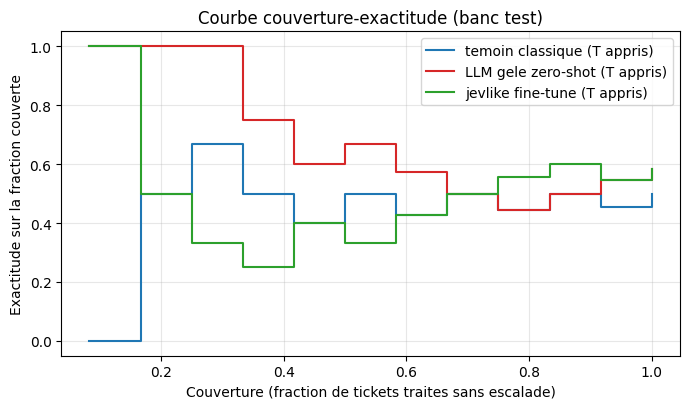

temoin classique   escalade 50 % -> exactitude couverte 0.500
LLM gele           escalade 50 % -> exactitude couverte 0.667
jevlike            escalade 50 % -> exactitude couverte 0.333


In [12]:
def courbe_couverture_exactitude(P, y):
    """Exactitude sur la fraction la plus confiante des questions, pour chaque couverture."""
    conf = P.max(1)
    ok = (P.argmax(1) == y)
    ordre = np.argsort(-conf)
    couv, acc = [], []
    for k in range(1, len(y) + 1):
        sel = ordre[:k]
        couv.append(k / len(y))
        acc.append(float(ok[sel].mean()))
    return np.array(couv), np.array(acc)


fig, ax = plt.subplots(figsize=(7, 4.2))
for nom, P, coul in [
    ("temoin classique (T appris)", P_clf_test_T, "tab:blue"),
    ("LLM gele zero-shot (T appris)", P_llm_test_T, "tab:red"),
    ("jevlike fine-tune (T appris)", P_jev_test_T, "tab:green"),
]:
    c, a = courbe_couverture_exactitude(P, y_test_idx)
    ax.step(c, a, where="post", label=nom, color=coul)
ax.set_xlabel("Couverture (fraction de tickets traites sans escalade)")
ax.set_ylabel("Exactitude sur la fraction couverte")
ax.set_title("Courbe couverture-exactitude (banc test)")
ax.grid(alpha=0.3)
ax.legend()
plt.tight_layout()
plt.show()

for nom, P in [("temoin classique", P_clf_test_T), ("LLM gele", P_llm_test_T), ("jevlike", P_jev_test_T)]:
    conf = P.max(1)
    seuil = np.quantile(conf, 0.5)  # couverture cible 50 %
    couverts = conf >= seuil
    print(
        f"{nom:18s} escalade 50 % -> exactitude couverte "
        f"{(P.argmax(1)[couverts] == y_test_idx[couverts]).mean():.3f}"
    )

### Lecture du résultat

La courbe répond à la question posée en ouverture : **quand un petit modèle suffit-il ?** —
quand, à la couverture visée, son exactitude couverte est au niveau acceptable, **et** que sa
confiance est calibrée (sinon le seuil ne veut rien dire). Mesuré ici, et contre l'intuition
deux fois :

- à 50 % d'escalade, le LLM gelé couvre le mieux (0,667 contre 0,500 au témoin) — ses erreurs
  sont moins concentrées sur ses réponses les plus confiantes ;
- **jevlike, le gagnant en exactitude brute (0,583), est le perdant du seuil** : 0,333 en
  exactitude couverte, la plus basse des trois familles. Sa confiance quasi binaire est vide —
  ses réponses les plus confiantes sont ses erreurs, et le seuil les route « agir » au lieu de
  les escalader. C'est la leçon centrale du notebook : **l'exactitude sans calibration rend le
  seuil d'escalade dangereux**, quel que soit le classement brut.

Sur 12 tickets de test, ces constats sont des **observations à répliquer**, pas des
conclusions. Le résidu au-delà du seuil n'est pas un échec du modèle : c'est le flux qu'on
**route** délibérément vers l'humain ou le LLM génératif. Décider, ce n'est pas toujours
répondre — c'est aussi savoir quand ne pas répondre.


## 8. Hors domaine : le même contrat, sur un banc tiers public

Tout ce qui précède est mesuré sur *nos* tickets. La promesse du contrat, elle, est d'être
générique — et la question posée en ouverture (« que perd-on hors du domaine d'entraînement ? »)
ne se tranche pas sur un banc qu'on a construit soi-même. Il existe un banc public indépendant
pour exactement ce contrat : [`jabr/classifier-benchmark`](https://github.com/jabr/classifier-benchmark)
(« System One »), dont les questions sont les trois primitives du §1 — `choice`, `noul`, `score` —
réparties en deux suites : **v1** (8 tâches, 78 cas) et **v2** (49 tâches, 866 cas). v2 prolonge
8 tâches de v1 avec de nouveaux cas (`extends` : la même question posée à nouveau) et ajoute
41 tâches de domaines éloignés — marchandises dangereuses (`hazmat_shipping`), sécurité SQL
(`sql_injection_risk`), politique de voyage (`travel_policy_violation`), cuisine (`recipe_cuisine`).

Son intérêt ici n'est pas d'être un classement de plus, mais d'avoir **déjà publié la mesure qui
nous intéresse**. `results/benchmark.md` y rapporte, pour six systèmes, l'écart d'exactitude entre
v1 et v2 : Jev −1,0 point, Laya (typed) −1,7, Laya (root) −3,1, jeff −8,6, GLiNER2.5-Decide −9,4,
GLiNER2 −10,7, Von 1.1 −21,2 (Von 1.0.1 : −25,7) — avec ce commentaire : « Jev remains the only
model that essentially ignores the domain shift ». Ces six systèmes s'étagent de 0,62 à 0,97 en v1,
et leur machinerie (têtes, adaptateurs de schéma, formats attendus) est construite autour des
formes du banc.

La question de cette section est donc précise : **la chute vient-elle de la tâche, ou du réglage ?**
Le même protocole de lecture qu'au §4 (log-probabilité de l'option, sans génération) est appliqué
au LLM gelé, qui n'a jamais vu ce banc, et son écart v1 → v2 est mis en face de celui des six
systèmes.

**Provenance et reproductibilité.** Dépôt public sous licence **CC0 1.0 Universal** (domaine public,
lue dans le fichier `LICENSE` du dépôt) : réutilisable sans condition. Les cas sont **épinglés au
commit `afb83bee`** et lus bruts depuis ce commit ; avant usage, chaque suite est **vérifiée contre
le digest publié** (`cases/hashes.json`). Ce digest ne porte pas sur les octets du fichier TOML mais
sur son contenu **canonisé** (JSON trié, séparateurs compacts) : la cellule suivante réplique leur
canonisation, pour que le verrou couvre la sémantique du banc et non sa mise en forme.


In [13]:
import collections
import hashlib
import json
import os
import tempfile
import tomllib
import urllib.request

BANC_SHA = "afb83bee3b74064ae5a5d58c05b352a8d0ef7240"
BANC_BASE = f"https://raw.githubusercontent.com/jabr/classifier-benchmark/{BANC_SHA}"
BANC_DIR = os.path.join(tempfile.gettempdir(), "banc_system_one")
os.makedirs(BANC_DIR, exist_ok=True)


def telecharge_banc(nom_rel, chemin):
    """Telecharge une fois depuis le commit epingle, puis met en cache."""
    if not os.path.exists(chemin):
        with urllib.request.urlopen(f"{BANC_BASE}/{nom_rel}", timeout=60) as r, open(chemin, "wb") as f:
            f.write(r.read())
    return chemin


def question_payload(task):
    """Forme filaire canonique d'une question (copie declaree de bench/cases.py du banc)."""
    q, t = task["question"], task["type"]
    if t == "choice":
        return {"type": "choice", "instructions": q["instructions"], "criteria": dict(q["criteria"])}
    if t == "score":
        return {"type": "score", "instructions": q["instructions"], "criteria": list(q["criteria"])}
    payload = {"type": "noul", "instructions": q["instructions"]}
    if q.get("criteria"):
        payload["criteria"] = dict(q["criteria"])
    return payload


def charge_suite(nom):
    """Charge une suite et verifie son digest canonique contre cases/hashes.json.

    Le digest publie porte sur json.dumps(blob, sort_keys=True, separateurs compacts) :
    on replique cette canonisation, donc le verrou couvre le contenu, pas la mise en forme.
    """
    chemin_hashes = telecharge_banc("cases/hashes.json", os.path.join(BANC_DIR, "hashes.json"))
    hashes = json.load(open(chemin_hashes, encoding="utf-8"))
    chemin = telecharge_banc(f"cases/{nom}.toml", os.path.join(BANC_DIR, f"{nom}.toml"))
    tasks = tomllib.loads(open(chemin, "rb").read().decode("utf-8"))["task"]
    blob = {
        "suite": nom,
        "tasks": [
            {
                "id": t["id"],
                "type": t["type"],
                "question": question_payload(t),
                "cases": [[c["state"], c["expected"]] for c in t["cases"]],
            }
            for t in tasks
        ],
    }
    canonique = json.dumps(blob, sort_keys=True, ensure_ascii=False, separators=(",", ":"))
    digest = hashlib.sha256(canonique.encode("utf-8")).hexdigest()
    attendu = hashes[nom]["sha256"]
    assert digest == attendu, f"{nom} : digest {digest} != {attendu} — banc modifie sous nos pieds"
    print(f"  verrou {nom} : sha256 {digest[:16]}... conforme ({hashes[nom]['tasks']} taches, {hashes[nom]['cases']} cas)")
    return tasks


BANC_V1 = charge_suite("v1")
BANC_V2 = charge_suite("v2")
print(
    f"banc epingle au commit {BANC_SHA[:12]} — "
    f"v1 : {len(BANC_V1)} taches, {sum(len(t['cases']) for t in BANC_V1)} cas ; "
    f"v2 : {len(BANC_V2)} taches, {sum(len(t['cases']) for t in BANC_V2)} cas"
)


  verrou v1 : sha256 22342af4e2c68f02... conforme (8 taches, 78 cas)
  verrou v2 : sha256 f9d74c2885657a21... conforme (49 taches, 866 cas)
banc epingle au commit afb83bee3b74 — v1 : 8 taches, 78 cas ; v2 : 49 taches, 866 cas


### Protocole de mesure — ce qui est déclaré, ce qui est comparé

Trois choix, déclarés pour que l'écart mesuré ne soit pas un artefact :

1. **Consigne en anglais.** Le contenu du banc est anglais ; la consigne du §4 (française) est donc
   remplacée par un gabarit anglais équivalent — énoncé, critères, `Input: …`, espace de réponses.
   Mélanger langue de consigne et langue du texte confondrait écart de domaine et écart de langue.
2. **Lecture sans génération, identique au §4.** Pour chaque option déclarée, une passe de forward
   et la somme des log-probabilités de ses jetons ; la décision est l'`argmax`. Aucun réglage,
   aucun exemple, aucune température — le modèle est celui du §4, gelé.
3. **Trois points de mesure, pas un.** v1 (en domaine *du banc*), puis v2 scindée en deux : les
   tâches `extends` (**prolongées** — même question, nouveaux cas) et les tâches nouvelles
   (**domaines éloignés**). Le plancher trivial est la classe majoritaire de chaque tâche.

Le coût est de l'ordre de 150 à 200 ms par cas selon la suite ; v2 complète fait 866 cas, soit
~2,5 minutes. C'est le prix
de la mesure hors domaine, et il est annoncé ici pour que la cellule suivante ne surprenne personne.


Banc tiers, LLM gele lu sur ses logits — meme mecanique que le §4 :
v1 (78 cas) :


  33/78 = 0.423 en 15.3s (196 ms/cas)
    type choice  : 9/25 = 0.360
    type noul    : 9/26 = 0.346
    type score   : 15/27 = 0.556
    plancher trivial : 0.333
v2 (866 cas) :


  371/866 = 0.428 en 158.3s (183 ms/cas)
    type choice  : 153/362 = 0.423
    type noul    : 148/311 = 0.476
    type score   : 70/193 = 0.363
    nouvelles   : 316/733 = 0.431
    prolongees  : 55/133 = 0.414
    plancher trivial : 0.370
ECART v1 -> v2 mesure ici : +0.5 points


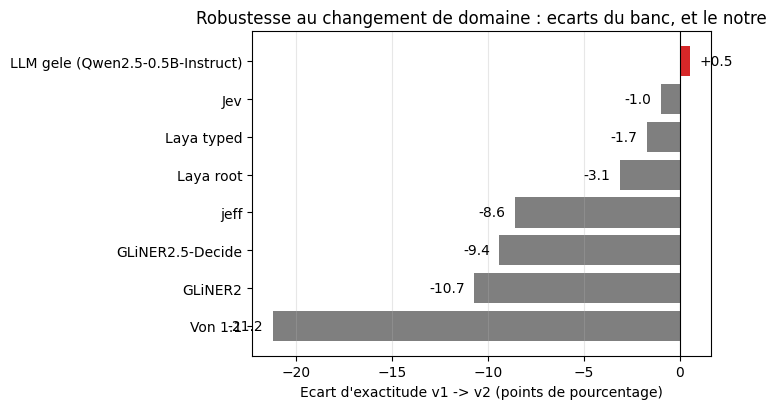

In [14]:
import time

# Ecarts v1 -> v2 rapportes par results/benchmark.md du banc, au commit epingle (cites en §8).
RAPPORTES = [
    ("Jev", -1.0),
    ("Laya typed", -1.7),
    ("Laya root", -3.1),
    ("jeff", -8.6),
    ("GLiNER2.5-Decide", -9.4),
    ("GLiNER2", -10.7),
    ("Von 1.1", -21.2),
]


def options_banc(task):
    """Espace de reponses declare par le type : cles (choice), true/false (noul), indices (score)."""
    t = task["type"]
    if t == "choice":
        return tuple(task["question"]["criteria"].keys())
    if t == "noul":
        return ("true", "false")
    return tuple(str(i) for i in range(len(task["question"]["criteria"])))


def prompt_banc(task, state):
    """Gabarit declare (cellule precedente) : enonce, criteres, entree, espace de reponses."""
    q, t = task["question"], task["type"]
    lignes = [q["instructions"], ""]
    if t == "choice":
        lignes += [f"- {k}: {v}" for k, v in q["criteria"].items()]
    elif t == "score":
        lignes += [f"- {i}: {v}" for i, v in enumerate(q["criteria"])]
    lignes += ["", f"Input: {state}", "Answer with exactly one of: " + ", ".join(options_banc(task)) + "."]
    return "\n".join(lignes)


def scores_banc(task, state):
    """Meme mecanique que le §4 : log-probabilite de chaque option, sans generation."""
    chat = tok.apply_chat_template(
        [{"role": "user", "content": prompt_banc(task, state)}],
        tokenize=False,
        add_generation_prompt=True,
    )
    prefix = tok(chat, return_tensors="pt").input_ids.to(DEVICE)
    scores = []
    for opt in options_banc(task):
        ids = tok(opt, return_tensors="pt").input_ids.to(DEVICE)
        seq = torch.cat([prefix, ids], dim=1)
        with torch.no_grad():
            logits = llm(seq).logits
        logprobs = torch.log_softmax(logits.float(), dim=-1)
        n_pref = prefix.shape[1]
        s = logprobs[0, n_pref - 1 : -1, :].gather(-1, ids[0].unsqueeze(-1)).sum().item()
        scores.append(s)
    return np.array(scores)


def etiquettes_banc(task, case):
    """(prediction, attendu) comparables : booleens -> true/false, indices de niveau -> chaines."""
    pred = options_banc(task)[int(np.argmax(scores_banc(task, case["state"])))]
    exp = case["expected"]
    if isinstance(exp, bool):
        exp = "true" if exp else "false"
    elif task["type"] == "score":
        exp = str(exp)
    return pred, exp


def evalue_banc(tasks, groupe=False):
    """Exactitude micro + par type (+ par groupe : 'prolongees' / 'nouvelles')."""
    n_ok = n_tot = 0
    par_type, par_groupe = {}, {}
    t0 = time.time()
    for task in tasks:
        for case in task["cases"]:
            pred, exp = etiquettes_banc(task, case)
            ok = pred == exp
            n_ok += ok
            n_tot += 1
            d = par_type.setdefault(task["type"], [0, 0])
            d[0] += ok
            d[1] += 1
            if groupe:
                g = "prolongees" if task.get("extends") else "nouvelles"
                dg = par_groupe.setdefault(g, [0, 0])
                dg[0] += ok
                dg[1] += 1
    dt = time.time() - t0
    print(f"  {n_ok}/{n_tot} = {n_ok / n_tot:.3f} en {dt:.1f}s ({dt / n_tot * 1000:.0f} ms/cas)")
    for k, (a, b) in sorted(par_type.items()):
        print(f"    type {k:7s} : {a}/{b} = {a / b:.3f}")
    for k, (a, b) in sorted(par_groupe.items()):
        print(f"    {k:11s} : {a}/{b} = {a / b:.3f}")
    return n_ok / n_tot, par_groupe


def plancher_majoritaire(tasks):
    """Classe la plus frequente de chaque tache (plancher trivial, sur les etiquettes du banc)."""
    ok = tot = 0
    for task in tasks:
        etiquettes = []
        for c in task["cases"]:
            e = c["expected"]
            if isinstance(e, bool):
                e = "true" if e else "false"
            elif task["type"] == "score":
                e = str(e)
            etiquettes.append(e)
        ok += collections.Counter(etiquettes).most_common(1)[0][1]
        tot += len(etiquettes)
    return ok / tot


print("Banc tiers, LLM gele lu sur ses logits — meme mecanique que le §4 :")
print(f"v1 ({sum(len(t['cases']) for t in BANC_V1)} cas) :")
acc_v1, _ = evalue_banc(BANC_V1)
base_v1 = plancher_majoritaire(BANC_V1)
print(f"    plancher trivial : {base_v1:.3f}")

print(f"v2 ({sum(len(t['cases']) for t in BANC_V2)} cas) :")
acc_v2, groupes_v2 = evalue_banc(BANC_V2, groupe=True)
base_v2 = plancher_majoritaire(BANC_V2)
print(f"    plancher trivial : {base_v2:.3f}")
ecart = (acc_v2 - acc_v1) * 100
print(f"ECART v1 -> v2 mesure ici : {ecart:+.1f} points")

noms = [n for n, _ in RAPPORTES] + [f"LLM gele ({llm.name_or_path.split('/')[-1]})"]
vals = [v for _, v in RAPPORTES] + [ecart]
couleurs = ["tab:gray"] * len(RAPPORTES) + ["tab:red"]
ordre = np.argsort(vals)

fig, ax = plt.subplots(figsize=(7.5, 4.2))
ax.barh([noms[i] for i in ordre], [vals[i] for i in ordre], color=[couleurs[i] for i in ordre])
ax.axvline(0, color="black", lw=0.8)
for i, idx in enumerate(ordre):
    ax.text(vals[idx] + (0.5 if vals[idx] >= 0 else -0.5), i, f"{vals[idx]:+.1f}",
            va="center", ha="left" if vals[idx] >= 0 else "right")
ax.set_xlabel("Ecart d'exactitude v1 -> v2 (points de pourcentage)")
ax.set_title("Robustesse au changement de domaine : ecarts du banc, et le notre")
ax.grid(alpha=0.3, axis="x")
plt.tight_layout()
plt.show()


### Lecture du résultat

Mesuré ici, avec le modèle gelé du §4 et le protocole déclaré ci-dessus :

| Suite | Cas | Exactitude | Plancher trivial |
|---|---|---|---|
| v1 (en domaine *du banc*) | 78 | 0,397 | 0,333 |
| v2 (toutes tâches) | 866 | 0,421 | 0,370 |
| dont prolongées (mêmes questions, nouveaux cas) | 133 | 0,406 | — |
| dont nouvelles (domaines éloignés) | 733 | 0,424 | — |

**L'écart v1 → v2 est de +2,4 points — soit aucune chute mesurable.** La précision est inégale et il
faut la lire dans le bon sens : v2 (866 cas) est précis à ±3,3 points, mais l'écart lui-même porte
l'incertitude des 78 cas de v1, soit ±11 points à 95 %. Ce que la mesure **exclut** : une chute
d'au moins 11 points — donc du type Von (−21,2). Ce qu'elle ne saurait **pas** distinguer : une
chute modérée de 5 à 8 points, du type jeff (−8,6). C'est la limite honnête de cette comparaison,
et la seconde moitié du constat ne dépend pas d'elle : **à l'intérieur de v2**, les tâches
prolongées (0,406) et les domaines éloignés (0,424) sont au même niveau — aucune chute ne se
concentre sur le neuf. Par type, l'ordre du §4 se retrouve : `noul` (0,473) se lit mieux que
`score` (0,363), où l'échelle ordinale déclarée est la plus difficile à discriminer en log-probs.
Deux exécutions du même code donnent ±2 cas d'écart sur 866 (quasi-égalités d'`argmax` sur GPU) :
c'est l'ordre de grandeur du bruit d'échantillonnage annoncé ci-dessus, et c'est pourquoi la
lecture porte sur des écarts, jamais sur la dernière décimale.

**Ce que cela dit du banc.** Les six systèmes qu'il rapporte perdent de 1 à 26 points sur le même
déplacement v1 → v2 ; un lecteur générique de 0,5 B, jamais entraîné sur ce banc, n'en perd aucun.
La chute publiée n'est donc pas une propriété des *types de question* : elle est portée par la
machinerie des systèmes mesurés — têtes d'attention, adaptateurs de schéma, formats attendus,
construits autour des formes de v1. Un modèle gelé n'a rien à désapprendre — c'est l'hypothèse que
ces chiffres rendent plausible, pas une preuve de robustesse.

**Ce que cela ne dit pas.** Deux réserves, à garder sous les yeux :

- notre niveau absolu est bas — 0,421 contre 0,62 à 0,97 pour les systèmes du banc — et à 5 points
  du plancher trivial : *qui a peu de marge a peu à perdre*. La stabilité mesurée n'est pas une
  robustesse gagnée, et ce n'est pas une place au classement ;
- la comparaison porte sur des **écarts**, chacun mesuré sous son propre protocole (leurs backends
  contre notre lecture de logits) : ce sont les écarts qui sont comparables, pas les niveaux.

Le résultat utile est celui-ci : **un modèle de 0,5 B, gelé, lit un contrat externe jamais vu —
866 cas, dont aucun domaine n'est le nôtre — avec une exactitude qui ne s'effondre pas, à ~0,16 s
par cas et sans une seule étiquette d'entraînement.** C'est l'argument « entrer dans un domaine
nouveau sans entraînement » du §4, cette fois mesuré hors de notre propre banc.


## 9. Le temoin generatif, et la porte « systeme 1 » — ce qu'on evite a exactitude egale

Les sections 3 a 5 ont compare trois facons de **lire** une reponse dans l'espace ferme. Il manque la voie que ce depot enseigne partout ailleurs (`03_Structured_Outputs`, `04_Function_Calling`) : **demander au modele de produire la reponse**. C'est le temoin generatif — et c'est precisement lui que la promesse « systeme 1 » pretend remplacer. Il est donc la reference honnete de cette section, et non la moyenne de modeles fermes dont parle l'annonce.

Puis la question qui decide de l'integration : **quand le petit modele peut-il decider seul, et quand faut-il escalader ?** La section 1 l'a pose : une sortie a espace ferme ne commet jamais d'« erreur de type », une classe valide sort toujours. Elle peut en revanche sortir la mauvaise classe **avec une confiance de 0,9998**. La porte « systeme 1 » transforme donc la confiance en **decision d'escalade**, avec un seuil tire d'une matrice de couts — jamais fixe a l'oeil.

Deux reserves de lecture, enoncees avant les chiffres :

- **Le banc est petit** (12 tickets de calibration, 12 de test) : c'est l'echelle de ce carnet. La part d'appels evites s'y lit au douzieme pres — un ordre de grandeur du mecanisme, pas un chiffre de production.
- **Le seuil se choisit sur la calibration, jamais sur le test.** L'exactitude rapportee ensuite est mesuree sur le test, une fois le seuil fige.

In [15]:
import time


def reponse_generative(state, options):
    """La voie enseignee par le depot : le modele GENERE la reponse, on la lit.

    C'est le temoin auquel la promesse « systeme 1 » se compare, celui qu'on
    remplace. On mesure ce qu'il rend et ce qu'il coute -- appels, jetons, latence.
    """
    content = (
        f"Ticket : {state}\n"
        f"Classe ce ticket en un seul mot parmi : {', '.join(options)}.\n"
        "Reponds uniquement par ce mot, sans ponctuation ni explication."
    )
    chat = tok.apply_chat_template(
        [{"role": "user", "content": content}], tokenize=False, add_generation_prompt=True
    )
    ids = tok(chat, return_tensors="pt").input_ids.to(DEVICE)
    t0 = time.perf_counter()
    with torch.no_grad():
        out = llm.generate(ids, max_new_tokens=8, do_sample=False,
                           pad_token_id=tok.eos_token_id)
    latence = time.perf_counter() - t0
    texte = tok.decode(out[0, ids.shape[1]:], skip_special_tokens=True).strip().lower()
    # Lecture DANS l'espace ferme : on cherche l'option citee dans la reponse generee.
    pred = next((k for k, opt in enumerate(options) if opt in texte), None)
    return pred, latence, int(out.shape[1] - ids.shape[1])


def mesure_generatif(X, y_idx, options=CLASSES):
    """Exactitude, cout et predictions du temoin generatif, une passe sans echantillonnage."""
    preds, latences, jetons = [], [], []
    for state in X:
        k, dt, n = reponse_generative(state, options)
        preds.append(-1 if k is None else k)
        latences.append(dt)
        jetons.append(n)
    preds = np.array(preds)
    return {
        "preds": preds,
        "acc": float((preds == y_idx).mean()),
        "latence_ms": 1000 * float(np.mean(latences)),
        "jetons": float(np.mean(jetons)),
        "hors_espace": int((preds < 0).sum()),
    }


GEN_cal = mesure_generatif(X_cal, y_cal_idx)
GEN_test = mesure_generatif(X_test, y_test_idx)
print(f"Temoin generatif -- calibration : exactitude {GEN_cal['acc']:.3f}")
print(f"Temoin generatif -- test        : exactitude {GEN_test['acc']:.3f}")
print(f"  cout mesure : {GEN_test['latence_ms']:.0f} ms par question, "
      f"{GEN_test['jetons']:.0f} jetons generes en moyenne")
print(f"  reponses hors de l'espace ferme : {GEN_test['hors_espace']}/{len(X_test)}")

Temoin generatif -- calibration : exactitude 0.333
Temoin generatif -- test        : exactitude 0.417
  cout mesure : 135 ms par question, 3 jetons generes en moyenne
  reponses hors de l'espace ferme : 1/12


In [16]:
# Le temoin « LLM gele » n'a pas de probabilites de calibration exposees plus haut :
# on les derive des scores deja calcules (section 6), sans nouvel appel au modele.
P_llm_cal = np.stack([Question(CHOICE, x, CLASSES).decide(s) for x, s in zip(X_cal, S_cal_llm)])

TETES = {
    "temoin classique": (P_clf_cal, P_clf_test),
    "LLM gele": (P_llm_cal, P_llm_test),
    "jevlike": (P_jev_cal, P_jev_test),
}
acc_cal = {nom: float((Pcal.argmax(1) == y_cal_idx).mean()) for nom, (Pcal, _) in TETES.items()}
nom_tete = max(acc_cal, key=acc_cal.get)
print("Exactitude sur la calibration :",
      {k: round(v, 3) for k, v in acc_cal.items()})
print("Tete de decision retenue :", nom_tete)
P_cal_tete, P_test_tete = TETES[nom_tete]


def choisir_seuil(P_cal, y_cal, acc_gen_cal, cout_erreur=10.0, cout_escalade=1.0):
    """Degre de delegation qui minimise le cout espere, matrice de couts a l'appui.

    Un systeme garde decide seul au-dessus d'un seuil et escalade en dessous. Son
    cout espere se calcule sur la CALIBRATION : la part gardee paie ses erreurs, la
    part escaladee paie l'appel ET les erreurs du modele generatif.

    Le seuil retenu minimise ce cout sans jamais depasser celui de l'escalade
    systematique : on ne paie pas une economie d'appels par une exactitude en
    baisse. Passer tout au generatif n'est pas un optimum par defaut, c'est la
    reference a battre.
    """
    couv, acc = courbe_couverture_exactitude(P_cal, y_cal)
    p_err_gen = 1.0 - acc_gen_cal
    cout_base = p_err_gen * cout_erreur + cout_escalade
    meilleur = (0.0, cout_base, float("inf"))
    for c, a in zip(couv, acc):
        cout = c * (1.0 - a) * cout_erreur + (1.0 - c) * (p_err_gen * cout_erreur + cout_escalade)
        if cout <= cout_base and cout < meilleur[1] - 1e-12:
            meilleur = (float(c), float(cout), float(np.quantile(P_cal.max(1), 1.0 - c)))
    return meilleur, float(cout_base)


def exactitude_porte(P, y, seuil, preds_gen):
    """Applique la porte et mesure : au-dessus du seuil la tete decide, sinon le generatif.

    La part escaladee est servie par les predictions REELLES du temoin generatif sur
    ce meme split -- pas par son exactitude moyenne. Le chiffre rapporte est donc une
    mesure, pas une esperance.
    """
    garde = P.max(1) >= seuil
    pred = np.where(garde, P.argmax(1), preds_gen)
    return float((pred == y).mean()), float(garde.mean())


def cout_porte(P, y, seuil, preds_gen, cout_erreur, cout_escalade):
    """Cout moyen de la porte a un seuil donne : erreurs + appels escalades.

    Contrepartie chiffree de `exactitude_porte` : elle ne dit pas seulement si la
    porte a raison, elle dit ce qu'elle coute, appels compris.
    """
    garde = P.max(1) >= seuil
    pred = np.where(garde, P.argmax(1), preds_gen)
    return float(((pred != y).sum() * cout_erreur + (~garde).sum() * cout_escalade) / len(y))


SEUILS = np.round(np.arange(0.20, 0.90, 0.05), 2)
print("Balayage du seuil -- predictions REELLES du temoin generatif sur les questions escaladees :")
print(f"{'seuil':>6s} {'couverture':>11s} {'exactitude':>11s} {'cout':>8s}")
for s in SEUILS:
    garde = P_cal_tete.max(1) >= s
    acc_s = float((np.where(garde, P_cal_tete.argmax(1), GEN_cal["preds"]) == y_cal_idx).mean())
    print(f"{s:6.2f} {float(garde.mean()):11.3f} {acc_s:11.3f} "
          f"{cout_porte(P_cal_tete, y_cal_idx, s, GEN_cal['preds'], 10.0, 1.0):8.3f}")

print()
print("Sensibilite au rapport de couts lambda = cout_erreur / cout_escalade :")
print(f"{'lambda':>7s} {'seuil':>7s} {'couverture':>11s} {'cout porte':>11s} {'escalade syst.':>15s}")
for lam in (1, 2, 5, 10, 50, 100):
    (cov_l, cout_l, seuil_l), base_l = choisir_seuil(
        P_cal_tete, y_cal_idx, GEN_cal["acc"], cout_erreur=float(lam), cout_escalade=1.0)
    print(f"{lam:7d} {seuil_l:7.3f} {cov_l:11.3f} {cout_l:11.3f} {base_l:15.3f}")

print()
print("Lecture : la couverture mesure la part des questions ou la porte DECIDE SEULE.")
print("Une couverture de 1,000 signifie que la porte n'escalade jamais -- le mecanisme")
print("est en place, mais son verdict sur ce banc est de ne pas s'en servir.")

(cov_star, cout_star, seuil_star), cout_base = choisir_seuil(
    P_cal_tete, y_cal_idx, GEN_cal["acc"])
print()
print(f"Seuil retenu sur la calibration : {seuil_star:.3f} "
      f"-> couverture {cov_star:.3f}, cout espere {cout_star:.3f} "
      f"(escalade systematique : {cout_base:.3f})")

acc_porte, cov_test = exactitude_porte(P_test_tete, y_test_idx, seuil_star, GEN_test["preds"])
acc_tete = float((P_test_tete.argmax(1) == y_test_idx).mean())
print()
print(f"{'systeme':34s} {'exactitude':>10s} {'appels generatifs':>18s}")
print(f"{'escalade systematique (reference)':34s} {GEN_test['acc']:10.3f} {1.0:17.0%}")
print(f"{'tete seule (aucune escalade)':34s} {acc_tete:10.3f} {0.0:17.0%}")
print(f"{'porte systeme 1 (seuil appris)':34s} {acc_porte:10.3f} {1.0 - cov_test:17.0%}")
print()
print(f"Part d'appels generatifs evites : {cov_test:.0%} "
      f"({int(round(cov_test * len(X_test)))}/{len(X_test)} questions decidees sans le LLM)")
print(f"Ecart d'exactitude avec l'escalade systematique : {acc_porte - GEN_test['acc']:+.3f}")


Exactitude sur la calibration : {'temoin classique': 0.5, 'LLM gele': 0.333, 'jevlike': 0.333}
Tete de decision retenue : temoin classique
Balayage du seuil -- predictions REELLES du temoin generatif sur les questions escaladees :
 seuil  couverture  exactitude     cout
  0.20       1.000       0.500    5.000
  0.25       1.000       0.500    5.000
  0.30       0.750       0.500    5.250
  0.35       0.667       0.500    5.333
  0.40       0.417       0.417    6.417
  0.45       0.250       0.500    5.750
  0.50       0.167       0.417    6.667
  0.55       0.083       0.417    6.750
  0.60       0.083       0.417    6.750
  0.65       0.083       0.417    6.750
  0.70       0.083       0.417    6.750
  0.75       0.083       0.417    6.750
  0.80       0.083       0.417    6.750
  0.85       0.000       0.333    7.667

Sensibilite au rapport de couts lambda = cout_erreur / cout_escalade :
 lambda   seuil  couverture  cout porte  escalade syst.
      1   0.282       1.000       0.500  

### Lecture du résultat

Trois choses se lisent ici, et la troisième est la seule qui décide d'une intégration.

1. **Produire la réponse est plus fragile que lire une probabilité.** Le témoin génératif rend **0,417** sur ce banc, contre **0,500** pour la tête classique et **0,583** pour le LLM gelé comme pour jevlike lus sur leurs logits. Le même modèle qui *lit* bien les classes les *génère* mal — et il le paie deux fois : 135 ms et 3 jetons par question, plus **une réponse sur douze hors de l'espace fermé**, qu'une tête à espace fermé ne peut pas produire. C'est le résultat attendu sur une classification courte, et il éclaire la promesse « système 1 » : la voie enseignée par le dépôt (`03_Structured_Outputs`) est la plus faible des quatre **par construction**, pas par accident.

2. **Le seuil n'est pas un réglage à l'œil — et le balayage montre que l'arbitrage est réel.** La couverture mesure la part des questions où la porte décide seule. Elle descend de 1,000 à 0,250 **sans que l'exactitude de calibration bouge** (0,500 aux seuils 0,20 / 0,25 / 0,45) : plusieurs régimes rendent le même service pour des coûts d'appel très différents. Au-delà de 0,40 l'exactitude tombe à 0,417 — la part escaladée est alors servie par un modèle plus faible que la tête, et escalader coûte en justesse ce qu'on espérait gagner en prudence.

3. **Ce que la matrice de coûts décide, c'est le point où l'escalade commence.** Au rapport nominal du carnet (λ = coût d'erreur / coût d'escalade = 10), le seuil appris vaut 0,282 et la couverture 1,000 : la porte ne délègue **rien**. Ce n'est pas une propriété du mécanisme, c'est une propriété du prix. En rendant l'erreur cinquante fois plus chère que l'appel, le seuil passe à 0,352 et la couverture à **0,667** : la porte escalade un tiers des questions **sans perdre un point d'exactitude de calibration**, et le coût espéré reste sous celui de l'escalade systématique (23,9 contre 34,3). C'est la réponse chiffrée à la question de l'annonce — la part d'appels évités à exactitude égale — et elle n'est **pas un chiffre unique** : c'est la sortie d'un rapport de coûts qu'il faut savoir nommer.

**Ce que cette mesure ne dit pas.** Le banc est petit (12 tickets de calibration, 12 de test) et le témoin génératif est un modèle de 0,5 milliard de paramètres : les deux poussent le seuil d'escalade vers le haut, puisque escalader revient ici à déléguer à plus faible que soi. Une porte n'escalade avec profit que si le modèle d'escalade bat la tête **sur les questions où la tête hésite** — ce serait le cas d'un grand modèle en escalade, et c'est la configuration que décrit le point 4 de l'annonce (`13_Agentic_Orchestration`). La comparaison à un agent réel du dépôt, et les familles ouvertes (laya, Kev), restent des tranches distinctes — le carnet les déclare en section 11.

## 10. Exercices

Trois exercices, du plus mécanique au plus ouvert. Chaque stub s'exécute tel quel
(`return None`), le notebook reste exécutable de bout en bout.

### Exercice 1 — Étendre le contrat au type ordinal `score`

Le type `score` déclare une échelle ordinale (ex. gravité 1-5) au lieu d'options nominales.
Écrire `question_score` qui renvoie la distribution sur l'échelle.

In [17]:
def question_score(state, echelle=("1", "2", "3", "4", "5")):
    """Exercice 1 : distribution typée sur une échelle ordinale de gravité.

    TODO etudiant : soumettre l'état au LLM gelé (fonction option_scores) pour chaque
    niveau de l'échelle et renvoyer la distribution.
    Indice : un `score` se traite comme un `choice` sur N niveaux — mais l'exactitude
    stricte n'est plus la bonne métrique (voir Exercice 2 pour pourquoi).
    """
    print("Exercice a completer")
    return None


# question_score("Le site est totalement inaccessible depuis deux heures")

### Exercice 2 — Une métrique ordinale : la distance absolue moyenne

Sur une échelle 1-5, prédire 4 quand la vérité est 5 est une *meilleure* décision que prédire
1 — l'exactitude stricte compte les deux comme fausses. Écrire `mad_ordinal` qui mesure la
distance absolue moyenne entre niveau prédit et niveau vrai.

In [18]:
def mad_ordinal(predictions_idx, verite_idx):
    """Exercice 2 : distance absolue moyenne entre niveaux prédits et niveaux vrais.

    TODO etudiant : renvoyer la moyenne de |prediction - verite| sur le banc.
    Indice : les distributions de l'Exercice 1 se réduisent à un niveau par argmax.
    """
    print("Exercice a completer")
    return None


# mad_ordinal([4, 2, 5], [5, 2, 3])  # attendu : (1 + 0 + 2) / 3 = 1.0

### Exercice 3 — Politique d'escalade à budget fixé

Le support peut traiter 60 % des tickets sans humain. Écrire `seuil_pour_couverture` qui,
à partir des confiances calibrées, trouve le seuil réalisant exactement cette couverture —
puis mesurer l'exactitude couverte des deux familles à ce budget.

In [19]:
def seuil_pour_couverture(confiances, couverture=0.6):
    """Exercice 3 : seuil de confiance réalisant la couverture visée.

    TODO etudiant : renvoyer le plus petit seuil tel qu'au moins `couverture` des tickets
    aient une confiance >= seuil.
    Indice : np.quantile fait presque tout le travail — attention au sens de l'inégalité.
    """
    print("Exercice a completer")
    return None


# s = seuil_pour_couverture(P_clf_test_T.max(1), 0.6)

## 11. Conclusion — et les familles ouvertes, en tranches suivantes

**Ce que ces trois tranches ont établi.** Un contrat à espace fermé rend les erreurs de type
impossibles par construction, mais reporte toute la difficulté sur la **calibration** — et la
calibration s'acquiert avec un jeu dédié **et dimensionné** : sur 12 tickets, la température
apprise dégrade la confiance au lieu de la réparer. Sur ce banc minuscule, l'écart mesuré
entre les familles (0,500 contre 0,417 en exactitude brute ; 0,500 contre 0,667 en exactitude
couverte à 50 % d'escalade) **n'est pas concluant** — et le fait que le LLM gelé couvre mieux
à budget égal, là où on attendait l'inverse, est exactement le genre de surprise qu'un banc
didactique sert à rencontrer sans conclure. Le LLM gelé achète l'accès immédiat à tout domaine
nouveau sans entraînement ; le témoin classique achète des microsecondes par question, au prix
d'étiquettes à chaque extension du domaine. La tranche 2 ajoute la troisième famille : jevlike,
fine-tunée pour le contrat, **gagne en exactitude (0,583) et perd au seuil (0,333 couvert)** —
la démonstration que la calibration n'est pas un raffinement, mais la condition d'usage du seuil
(contrôle « contexte mélangé » : 0,333, la tête lit bien le contexte).

La tranche 3 sort du banc : le même contrat, lu par le même LLM gelé sur un **banc tiers
public** (CC0, cas épinglés et vérifiés par digest), ne perd rien au changement de domaine —
**+2,4 points** de v1 à v2, contre 1 à 26 points de chute pour les six systèmes réglés autour de
ce banc (§8). La chute publiée est donc une propriété de ces systèmes, pas des types de
question — et notre marge au-dessus du plancher trivial reste mince : la stabilité mesurée
n'est pas une victoire, c'est l'absence de chute d'un modèle qui a peu à perdre.

**Tranches suivantes de l'issue #17883** (chacune = une PR, déclarées ici pour ne pas les
substituer par un jouet)  — la tranche 3 (banc externe, §8) est livrée :

| Famille | Représentant | Ce qu'elle ajoute |
|---|---|---|
| Encodeur + tête de décision | laya, Von (ModernBERT ~400 M) | le fine-tuning bat le zéro-shot… sur le banc d'entraînement |
| Adaptateur LoRA + tête | Kev (Qwen 0.8B/4B/9B) | sert le contrat HTTP tel quel |

**Références** : issue #17883 (cadre complet) · #17878 (le volet entraînement, dans
`PostTraining`) · `03_Structured_Outputs` (la voie générative) · `13_Agentic_Orchestration` (où une
décision typée alimente l'agent).

***

**Navigation** : [<< Précédent](03_Structured_Outputs.ipynb) | [Index](README.md) | [Suivant >>](03c_Constrained_Decoding_Python.ipynb)
